# [LAB13] 딥러닝 > 비정형 데이터 > 1. CNN | Pneumonia MNIST

폐렴의 이진 분류를 위한 엄선된 흉부 X선 이미지 모음:

## #01. CNN의 이해

이미지를 분석하는데 사용되는 딥러닝 알고리즘의 하나.

이미지를 작은 단위로 쪼개어 각 부분을 분석하는 것이 핵심

이미지를 인식하기 위한 패턴을 찾는데 유용함.

> ex) 휴대폰 잠금해제 인식, 자동차 자율주행 같은 분야

CNN은 다른 신경망과 마찬가지로 입력 계층(독립변수), 출력 계층(종속변수) 및 두 계층 사이의 여러 은닉 계층으로 구성됨. (즉, 지도학습의 일종)

### [1] CNN의 주요 개념

#### (1) 합성곱(Convolutional)

합성곱 연산은 두 함수 $f$, $g$ 가운데 하나의 함수를 반전(reverse), 전이(shift)시킨 다음, 다른 하나의 함수와 곱한 결과를 적분하는 것을 의미

> 사진에 필터를 적용하여 색감을 변경하는 원리

##### 2차원 입력 데이터(Shape: (5:5))를 1개의 필터로 합성곱 연산 수행

![img](res/cnn0.png)

- 이미지 파일은 2차원 배열로 이루어져 있다.
- 이미지 파일을 의미하는 2차원 배열의 각 원소는 픽셀에 표시되는 색상을 의미한다.
- 이미지 파일을 의미하는 2차원 배열의 각 원소에 일정한 값을 연산한다는 것은 색상을 일관되게 변환한다는 것을 의미

#### (2) 채널 (Channel)

이미지 픽셀 하나하나는 색상을 의미하는 `0~255` 사이의 실수이다.

흑백 이미지는 하나의 색상으로 명도만을 표현하면 되지만 컬러 사진은 천연색을 표현하기 위해서 각 픽셀을 RGB 3개의 실수로 표현한 3차원 데이터로 구성된다.

| 구분 | 구조 | 예시 |
|---|---|---|
| 흑백사진 | 2차원 데이터(1개 채널) | 높이가 39픽셀이고 폭이 31픽셀인 흑백 사진 데이터의 shape은 (39, 31, 1) |
| 컬러 이미지 | 3차원 데이터(RGB 3개의 채널) | 높이가 39 픽셀이고 폭이 31 픽셀인 컬러 사진 데이터의 shape은 (39, 31, 3) |

![img](res/channel.jpg)

#### (3) 필터 (Filter)

- 이미지의 특징을 찾아내기 위한 공용 파라미터
- Kernel 이라고도 한다. (CNN에서 Filter와 Kernel은 같은 의미)
- 필터는 일반적으로 (4x4)이나 (3x3)과 같은 정사각 행렬로 정의된다.
- CNN에서 학습의 대상은 필터이다.

### [2] 합성곱 계산 절차

입력 데이터를 지정된 간격으로 순회하며 채널별로 합성곱을 하고 모든 채널(컬러의 경우 3개)의 합성곱의 합을 Feature Map로 만든다.

필터는 지정된 간격으로 이동하면서 전체 입력데이터와 합성곱하여 Feature Map을 만든다.

아래 그림은 채널이 1개인 입력 데이터를 (3x3) 크기의 필터로 합성곱하는 과정을 설명한다.

![img](res/conv.png)

#### (1) Feature Map 과정

- 필터는 입력 데이터를 지정한 간격으로 순회하면서 합성곱을 계산한다.
- 여기서 지정된 간격으로 필터를 순회하는 간격을 Stride라고 한다.
- 아래 그림은 strid가 1로 필터를 입력 데이터에 순회하는 예제.
    > strid가 2로 설정되면 필터는 2칸씩 이동하면서 합성곱을 계산한다.

![img](res/filter.jpg)

#### (2) 멀티 채널 입력 데이터(컬러 이미지)에 필터를 적용한 합성곱 계산 절차

입력 데이터가 여러 채널을 갖을 경우 필터는 각 채널을 순회하며 합성곱을 계산한 후, 채널별 피처 맵을 만든다.

그리고 각 채널의 피처 맵을 합산하여 최종 피처 맵으로 반환

![img](res/conv2.jpg)

- Feature Map은 합성곱 계산으로 만들어진 행렬이다.
- 입력 데이터는 **채널 수와 상관없이 필터 별로 1개의 피처 맵**이 만들어 진다.

#### (3) Activation Map

하나의 Convolution Layer에 크기가 같은 여러 개의 필터를 적용할 수 있다. 이 경우에 Feature Map에는 필터 수 만큼의 채널이 만들어진다.

Convolution Layer의 입력 데이터를 필터가 순회하며 합성곱을 통해서 만든 Feature Map을 Activation Map이라고 한다.

Activation Map은 Feature Map 행렬에 활성 함수를 적용한 결과

즉, Convolution Layer의 최종 결과가 Activation Map

### [3] 패딩(Padding)

Filter와 Stride에 작용으로 Feature Map 크기는 입력데이터 보다 작다.

Convolution 레이어의 출력 데이터가 줄어드는 것을 방지하는 방법이 패딩

패딩은 입력 데이터의 외각에 지정된 픽셀만큼 특정 값으로 채워 넣는 것을 의미한다.

보통 패딩 값으로 0으로 채워 넣는다.

#### (1) padding 예시 (2px 추가)

(32x32x3) 데이터를 외각에 2 pixel을 추가하여 (36x36x3) 행렬을 만드는 예제

Padding을 통해서 Convolution Layer의 출력 데이터의 사이즈를 조절하는 기능이 외에, 외각을 “0”값으로 둘러싸는 특징으로 부터 인공 신경망이 이미지의 외각을 인식하는 학습 효과도 있다.

![img](res/padding.png)

### [4] Pooling Layer

Pooling Layer는 Convolution Layer의 출력 데이터(Feature Map 혹은 Activation Map)의 크기를 줄이거나 특정 데이터를 강조하는 용도로 사용된다.

Pooling Layer를 처리하는 방법으로는 Max Pooling과 Average Pooning, Min Pooling이 있다.

정사각 행렬의 특정 영역 안에 값의 최댓값을 모으거나 특정 영역의 평균을 구하는 방식으로 동작한다. 

![img](res/maxpulling.png)

#### (1) Max Pooling, Average Pooling

Max pooling과 Average Pooling의 동작 방식은 일반적으로 Pooing 크기와 Stride를 같은 크기로 설정하여 모든 원소가 한 번씩 처리 되도록 설정하는 것이다.

#### (2) Pooling 레이어 특징

- 학습대상 파라미터가 없음
- Pooling 레이어를 통과하면 행렬의 크기 감소
- Pooling 레이어를 통해서 채널 수 변경 없음

CNN에서는 주로 Max Pooling을 사용

---

## #02. 준비작업

### [1] 패키지 가져오기

In [1]:
import os
import numpy as np
import seaborn as sb

from pandas import DataFrame, read_csv
from matplotlib import pyplot as plt
from tqdm.keras import TqdmCallback
from datetime import datetime as dt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from keras_tuner import Hyperband

from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.losses import mse
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import AUC, F1Score

# CNN 모델 구축을 위한 레이어와 최적화, 손실함수, 콜백, 성능평가 지표 등 필요한 기능들
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout, Activation, Conv2D, MaxPool2D, Flatten

: 

### [2] 데이터셋 준비하기

원본 데이터셋은 아래 URL에서 다운로드 가능

여러 개의 이미지를 numpy 배열로 변환하여 하나의 파일로 묶은 형태

> https://www.kaggle.com/datasets/rijulshr/pneumoniamnist
>
> https://data.hossam.kr/tensor/pneumoniamnist.npz

파일을 내려받아서 ipynb 파일과 같은 위치에 배치한다.

In [ ]:
def load_npz(path):
    data = np.load(path)
    
    for key in data.files:
        print(f'{key} : {data[key].shape}')

    return data

In [ ]:
# pneumoniamnist.npz 없으면 PDF 링크(https://data.hossam.kr/tensor/pneumoniamnist.npz)에서 다운로드
import urllib.request
_npz_path = './pneumoniamnist.npz'
if not os.path.exists(_npz_path):
    print('pneumoniamnist.npz 다운로드 중...')
    urllib.request.urlretrieve('https://data.hossam.kr/tensor/pneumoniamnist.npz', _npz_path)
    print('다운로드 완료.')
else:
    print('pneumoniamnist.npz 파일이 이미 있습니다.')

In [ ]:
data = load_npz('./pneumoniamnist.npz')

train_images : (3882, 28, 28)
train_labels : (3882, 1)
val_images : (524, 28, 28)
val_labels : (524, 1)
test_images : (624, 28, 28)
test_labels : (624, 1)


In [ ]:
x_train = data['train_images']
y_train = data['train_labels']
x_val = data['val_images']
y_val = data['val_labels']
x_test = data['test_images']
y_test = data['test_labels']

#### (1) 임의의 이미지 출력하기

In [ ]:
for i in x_train[1]:
    for j in i:
        print("%03d" % j, end="")
    print()

115118117113114120123123132146164172168168185204199196191183172152125105124123115104
130137140135133138148153163168175174165159167179185181181181172156145142151146135121
134151167172171172175177178179180179171164167174177177184191187176175182160152138123
128139153163171176173168171176184188183177179186172174177178179176168160154146134123
151148145149163172168158156169186195189181183191185182169157165178167143158152145141
163162162165170167149129132151176192191185188196188175149133150179184169163158156158
148159168165152135116101120136162184191191194200172148120109119139159170169163161164
163175177156130116118125128138159180191192192194183152126116106101122152180172168170
167156145137129120116117111117140172192195198204178145116122134123120139169177177166
177166153142129116108106125130150178193193193198201170125101107116126143142158169165
170163157152144134129130131138157183197198199203187184155123119123119116146165179176
16516115715414813913713913914816718920120320320719019517213612011

#### 데이터 그려보기

/var/folders/wk/8tx_v8l94cqcwt2b6dzgdc2h0000gn/T/ipykernel_15591/860674527.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[i].set_title("label=%d, %s" % (label, label))


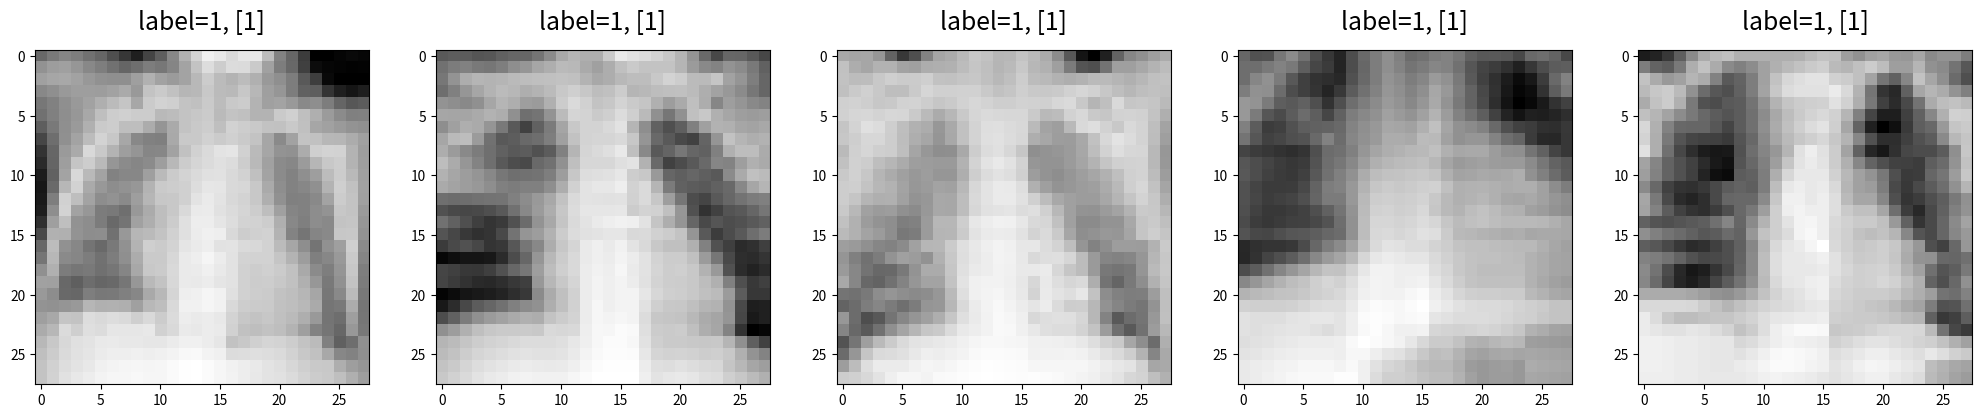

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(25, 5), dpi=100)

for i in range(0, len(ax)):
    train = x_train[i]
    label = y_train[i]
    ax[i].imshow(train, cmap="gray")
    ax[i].set_title("label=%d, %s" % (label, label))

## #03. 데이터 전처리

### [1] 종속변수에 대한 one-hot-encoding

이진 분류 이므로 필요없다.

### [2] 독립변수 전처리 - 훈련, 검증용 독립변수(이미지)의 차수 재설정

훈련 데이터의 shape가 (3882, 28, 28)라는 것은 가로 28, 세로 28 크기의 이미지가 3882장 이라는 의미.

즉, 28x28의 이차배열이 6만개가 존재하는 의미

즉, 3882개의 2차원 배열을 학습해야 하는 것 보다 3882개의 784(28*28)개의 원소를 갖는 1차원 배열을 학습하는 것이 학습 효율이 더 좋다.

#### (1) 훈련 데이터의 차수 확인

In [ ]:
x_train.shape

(3882, 28, 28)

#### (2) 차수 변경

In [ ]:
# 차원 변경 및 정규화 (0~1 범위로 스케일링)
x_train_reshape = x_train.reshape(
    x_train.shape[0], x_train.shape[1], x_train.shape[2], 1
).astype('float32') / 255.0

x_val_reshape = x_val.reshape(
    x_val.shape[0], x_val.shape[1], x_val.shape[2], 1
).astype('float32') / 255.0

x_test_reshape = x_test.reshape(
    x_test.shape[0], x_test.shape[1], x_test.shape[2], 1
).astype('float32') / 255.0

print(f"훈련 데이터 {x_train_reshape.shape} / 검증 데이터 {x_val_reshape.shape} / 테스트 데이터 {x_test_reshape.shape}")
print(f"픽셀 값 범위: [{x_train_reshape.min():.2f}, {x_train_reshape.max():.2f}]")

훈련 데이터 (3882, 28, 28, 1) / 검증 데이터 (524, 28, 28, 1) / 테스트 데이터 (624, 28, 28, 1)
픽셀 값 범위: [0.00, 1.00]


##### 라벨 데이터가 2차 배열로 되어 있으므로 1차 배열로 재구성

In [ ]:
y_train[:5]

array([[1],
       [1],
       [1],
       [1],
       [1]], dtype=uint8)

In [ ]:
y_train_reshape = y_train.reshape(-1)
y_test_reshape = y_test.reshape(-1)
y_val_reshape = y_val.reshape(-1)

y_train_reshape[:5]

array([1, 1, 1, 1, 1], dtype=uint8)

### [3] 이미지 데이터 정규화

**픽셀 값 정규화**
- 원본 이미지 픽셀 값: 0~255 범위
- 신경망 학습을 위해 0~1 범위로 정규화 (255로 나눔)
- 정규화하지 않으면 큰 값으로 인해 학습이 불안정하고 수렴이 어려움

**BatchNormalization과의 차이**
- 픽셀 정규화: 입력 데이터의 스케일을 0~1로 조정 (전처리 단계)
- BatchNormalization: 각 배치의 평균과 분산을 정규화 (학습 중 적용)
- 둘 다 필요하며 상호 보완적임

BatchNormalization은 Activation 레이어 이전에 사용되어야 함. 활성화 함수 적용 전에 데이터를 정규화하여 학습 안정성을 높임.

## #04. 훈련 모델 적합

### [1] 하이퍼 파라미터 튜닝 함수

( `Conv2D 적용 [-> BatchNormalization층 적용] -> MaxPool2D 적용 [-> Dropout]` )의 과정을 n번 반복 -> Flatten 레이어 추가 -> Dense층 n개 추가

* **Conv2D 층**
    - 영상이나 이미지의 특징을 확인하기 위한 함수
    - `filters`: 필터(커널)의 개수
    - `kernel_size`: 필터의 크기
    - `strides`: 필터의 이동 간격
    - `padding`: valid(패딩 없음), same(인풋과 아웃풋이 같도록 패딩)
    - `activation`: 활성화 함수
    - `input_shape`: 첫 레이어에 인풋으로 들어오는 크기
* **BatchNormalization (배치정규화)**
    - 신경망 입력데이터를 평균 0, 분산 1로 정규화해서 학습이 잘 이루어지도록 하는 방법
    - BatchNormalization 층에서 정규화를 수행하므로 별도의 정규화를 적용할 필요가 없다.
    - 만약 이 층을 적용하지 않는다면 학습 전에 별도의 정규화를 수행하는 것이 좋다.
* **MaxPool2D**
    - 컨볼루션 레이어의 출력 이미지에서 주요값만 뽑아 크기가 작은 출력 영상을 만든다.
    - `pool_size`: 축소시킬 필터의 크기(비율)
    - `strides`: 필터의 이동 간격. 기본값으로 pool_size를 갖는다.
    - 일반적으로 strides는 pool_size와 동일하게 적용되므로 생략하는 편.

In [ ]:
def tf_build(hp) -> Sequential:
    model = Sequential()

    # ------------------------#
    # Conv2D
    model.add(
        Conv2D(
            filters=hp.Choice("filters", values=[16, 32, 64]),
            kernel_size=hp.Choice("kernel_size", values=[3, 4, 5]),
            strides=hp.Choice("strides", values=[1, 2]),
            padding="same",
            input_shape=(28,28,1)
        )
    )

    # 표준화
    model.add(BatchNormalization())

    # Activation
    model.add(Activation("relu"))

    # MaxPool
    model.add(
        MaxPool2D(
            pool_size=hp.Choice("pool_size", values=[2, 3])
        )
    )

    # Dropout
    model.add(
        Dropout(
            hp.Choice("dropout", values=[0.0,0.05,0.1,0.2])
        )
    )

    # ------------------------#

    model.add(Flatten())

    # Dense Layer 튜닝
    model.add(
        Dense(
            units=hp.Choice("dense_units", values=[64,128,256,512])
        )
    )

    model.add(BatchNormalization())
    
    model.add(Activation("relu"))

    # Output
    # sigmoid 활성화 함수는 [0, 1] 범위의 확률을 출력해야 함
    # BatchNormalization이 중간에 들어가면 이 확률 범위가 왜곡됨
    # 최종 출력층에는 정규화가 불필요함
    model.add(Dense(1))
    model.add(Activation("sigmoid"))    # 이진 분류이므로 sigmoid 활성화 함수 사용

    # compile
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            AUC(name="auc")
        ],
    )

    return model

### [2] 학습하기

In [ ]:
tuner = Hyperband(
    hypermodel=tf_build,
    objective="accuracy",
    max_epochs=10,
    factor=3,
    seed=52,
    directory="tensor-tuning",
    project_name="xray_mnist_%s" % dt.now().strftime("%Y%m%d%H%M%S"),
)

tuner

/Users/leekh/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### [3] 하이퍼파라미터 튜닝 수행

In [ ]:
%%time

tuner.search(
    x_train_reshape,
    y_train_reshape,
    epochs=5,
    batch_size=32,
    validation_data=(x_val_reshape, y_val_reshape)
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters()

if not best_hps:
    raise ValueError("No best hyperparameters found.")

print(f"""best hyperparameters: {best_hps[0].values}""")

Trial 30 Complete [00h 00m 08s]
accuracy: 0.996393620967865

Best accuracy So Far: 0.9981967806816101
Total elapsed time: 00h 01m 45s
best hyperparameters: {'filters': 32, 'kernel_size': 3, 'strides': 2, 'pool_size': 2, 'dropout': 0.0, 'dense_units': 512, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}
CPU times: user 5min 37s, sys: 32.8 s, total: 6min 10s
Wall time: 1min 45s


### [4] 최종 모형 도출

> 11강 소스코드와 동일

In [ ]:
%%time

model = tuner.hypermodel.build(best_hps[0])

result = model.fit(
    #---------------------------------------------------
    x_train_reshape,                        # 학습 데이터 입력
    y_train_reshape,                        # 학습 데이터의 타겟값 (정답)
    #---------------------------------------------------
    epochs=500,                             # 전체 학습 데이터셋을 500회 반복하여 학습
    #---------------------------------------------------
    validation_data=(x_test_reshape, y_test_reshape),   # 검증 데이터 설정
    #---------------------------------------------------
    verbose=0,                              # 학습 과정 출력 생략
    callbacks=[
        TqdmCallback(verbose=1),            # 학습 진행 상황을 tqdm 형태로 보여주는 콜백 추가

        # 조기 종료 콜백
        # 너무 일찍 조기종료하면 모델이 충분히 학습되지 않고 에러율이 높게 나올 수 있음
        EarlyStopping(monitor='val_loss', patience=5, min_delta=0.001),

        # 학습률 감소 콜백: 검증 손실(val_loss)이 10회 연속 개선되지 않으면 학습률을 0.5배로 감소
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0, verbose=1)
    ] 
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

CPU times: user 16.6 s, sys: 2.86 s, total: 19.5 s
Wall time: 5.67 s


## #05 성능평가

> 11강 소스코드와 동일

### [1] 성능평가 지표

In [ ]:
train_eval = model.evaluate(x_train_reshape, y_train_reshape, verbose=0, return_dict=True)
test_eval = model.evaluate(x_test_reshape, y_test_reshape, verbose=0, return_dict=True)

# DataFrame 생성
final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, "Dataset", ["Train", "Test"])

# Gap 계산
for metric in ["loss", "accuracy", "auc"]:
    final_results[f"{metric}_gap"] = None
    final_results.loc[1, f"{metric}_gap"] = (
        final_results.loc[1, metric] - final_results.loc[0, metric]
    )

final_results

,Dataset,accuracy,auc,loss,loss_gap,accuracy_gap,auc_gap
0,Train,0.931,0.999,0.180,None,None,None
1,Test,0.861,0.881,0.819,0.639,-0.071,-0.117


### [2] 학습 과정 확인

In [ ]:
history_df = DataFrame(data=result.history)
history_df["epoch"] = history_df.index + 1

history_df.head()

,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate,epoch
0,0.956,0.975,0.122,0.625,0.506,2.419,0.001,1
1,0.982,0.994,0.056,0.625,0.500,3.919,0.001,2
2,0.984,0.997,0.044,0.625,0.500,4.561,0.001,3
3,0.991,0.998,0.031,0.678,0.880,1.323,0.001,4
4,0.992,0.998,0.025,0.655,0.748,2.256,0.001,5


### [3] 학습 결과 시각화

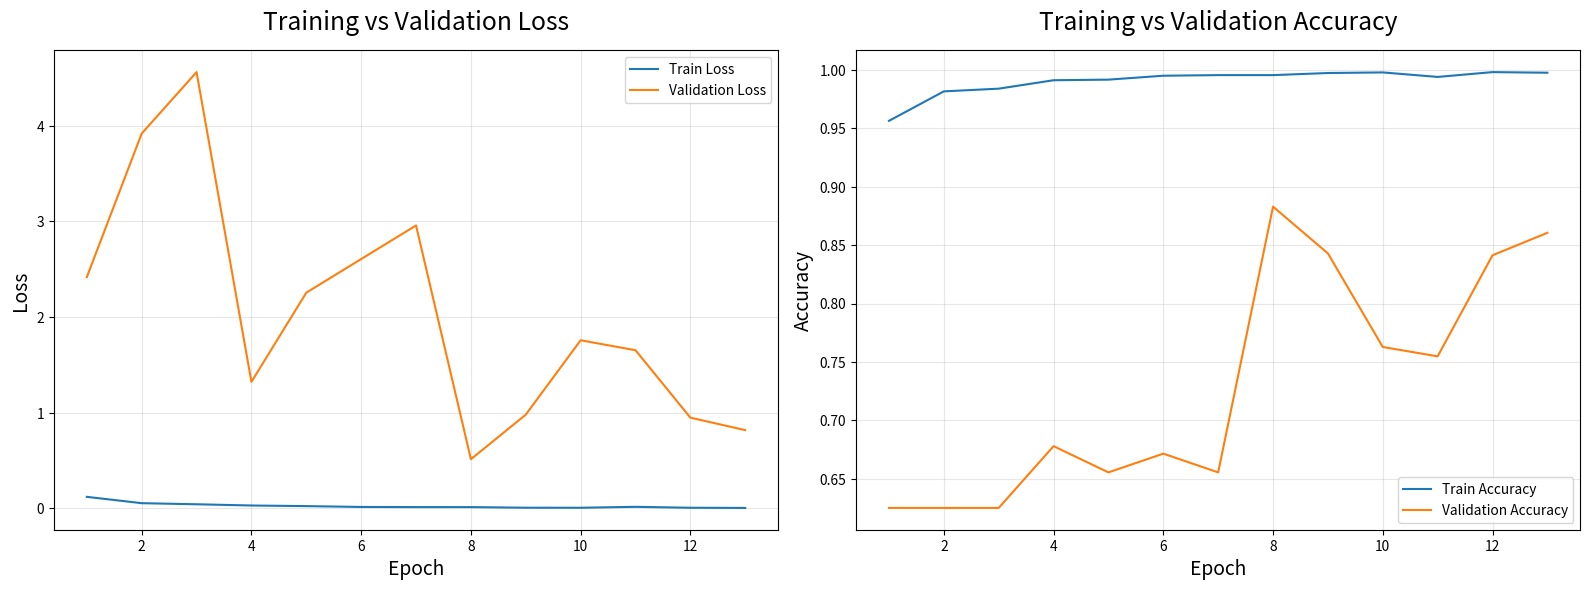

In [ ]:
figsize = (1600 / 100, 600 / 100)
fig, ax = plt.subplots(1, 2, figsize=figsize, dpi=100)
fig.subplots_adjust(wspace=0.2, hspace=0.2)

# 훈련데이터의 손실률
sb.lineplot(
    data=history_df,
    x="epoch",
    y="loss",   # <--- 평가지표 이름 명시
    ax=ax[0],
    label="Train Loss"
)

# 검증 데이터의 손실률
sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_loss",   # <--- 평가지표 이름 명시
    ax=ax[0],
    label="Validation Loss"
)

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training vs Validation Loss")

ax[0].grid(True, alpha=0.3)

# 훈련데이터의 정확도
sb.lineplot(
    data=history_df,
    x="epoch",
    y="accuracy",   # <--- 평가지표 이름 명시
    ax=ax[1],
    label="Train Accuracy"
)

# 검증 데이터의 정확도
sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_accuracy",   # <--- 평가지표 이름 명시
    ax=ax[1],
    label="Validation Accuracy"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training vs Validation Accuracy")

ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

### [4] 분류결과 확인

#### 분류값 얻기

In [ ]:
pred =  model.predict(x_test_reshape, verbose=0)
pred[: 5]

array([[9.9948806e-01],
       [9.9998748e-01],
       [9.9999970e-01],
       [5.8184384e-08],
       [7.0277464e-01]], dtype=float32)

### [2] 가장 큰 확률 값의 인덱스를 별도 리스트로 추출

In [ ]:
# 이진 분류이므로 0.5 임계값으로 클래스 결정
pred_classes = (pred > 0.5).astype(int).flatten()
pred_classes[:5]

array([1, 1, 1, 0, 1])

### [3] 데이터 비교

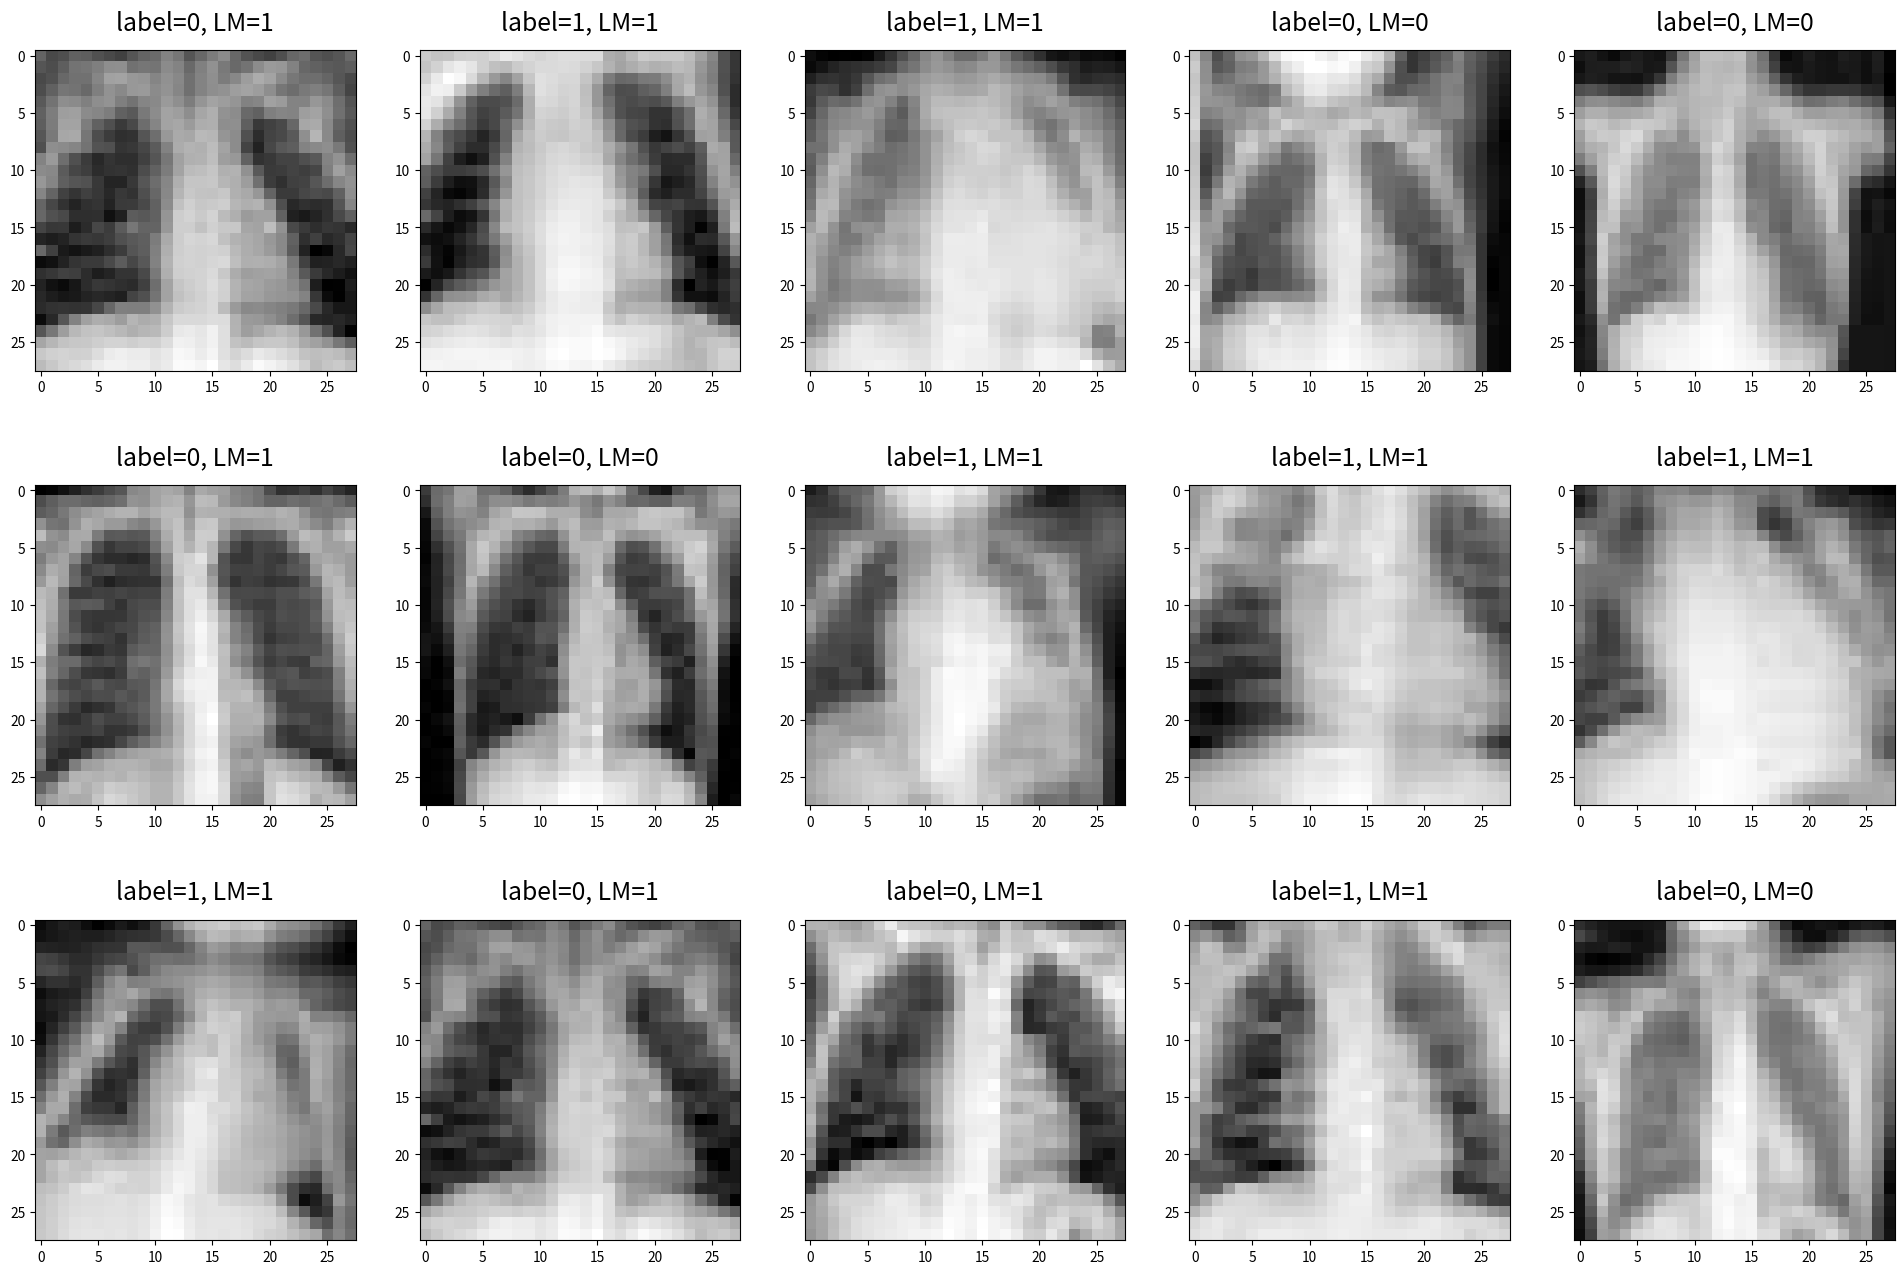

In [ ]:
row = 3
col = 5
fig, ax = plt.subplots(row, col, figsize=((col + 1) * 4, (row + 1) * 4), dpi=100)

size = row * col
length = len(y_test_reshape)

for i in range(0, size):
    k = np.random.randint(length)
    train = x_test[k]
    label = y_test_reshape[k]
    ax[i // col][i % col].imshow(train, cmap="gray")
    ax[i // col][i % col].set_title("label=%d, LM=%d" % (label, pred_classes[k]))

plt.show()
plt.close()

#### 혼동행렬 시각화

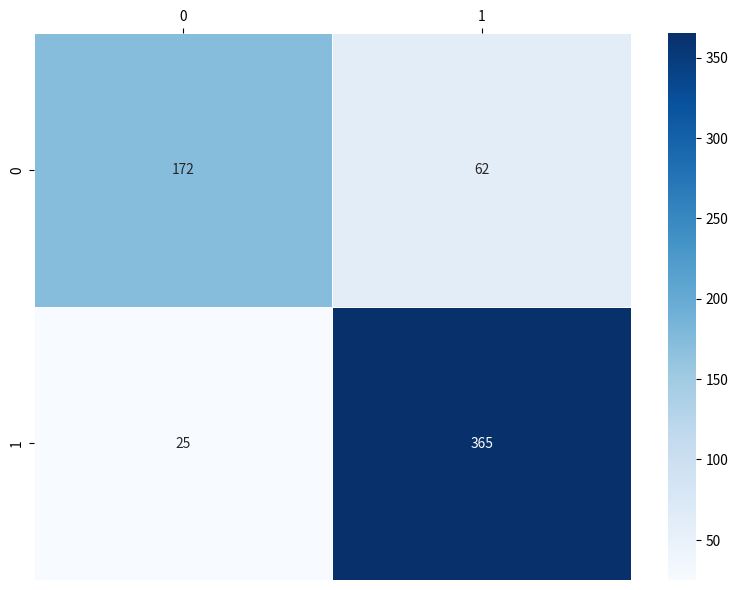

In [ ]:
cm = confusion_matrix(
    y_test_reshape,
    pred_classes
)

figsize = (800 / 100, 600 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

sb.heatmap(data=cm, annot=True, fmt="d", linewidth=0.5, cmap="Blues")
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()             # x축의 변수 이름을 상단으로 이동

plt.tight_layout()
plt.show()
plt.close()